In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D,AveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# plot settings
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['savefig.dpi'] = 600

In [9]:
import time

# Task 1
## Load CIFAR-10.


In [11]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1310s 8us/step


## Normalise Pixel values

In [12]:
# Normalise images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [13]:
# Apply one-hot encoding to class labels
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

## Print dataset dimensions.

In [14]:
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


## Display 10 Sample images

In [ ]:
# Define class categories
class_names=["Airplane","Automobile","Bird","Cat","Deer","Dog","Frog","Horse","Ship","Truck"]

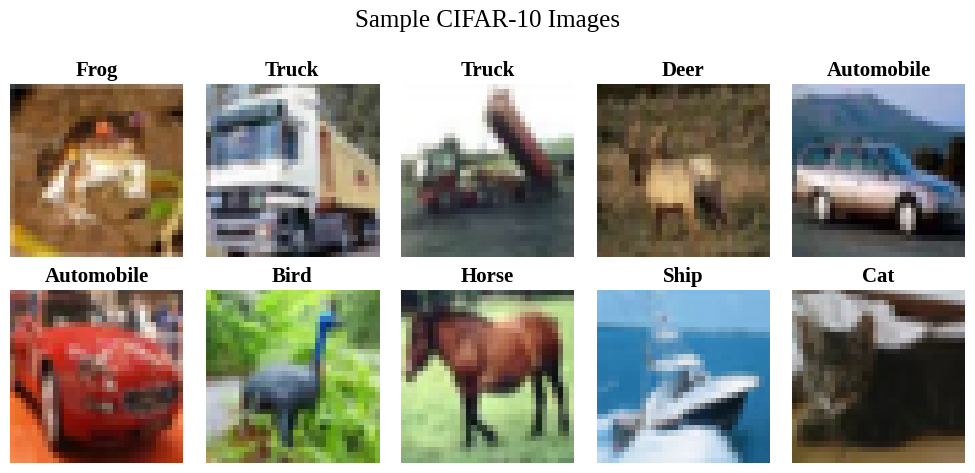

In [ ]:
# Plot sample images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig("SampleImages.png")
plt.show()

# Task 2: Transfer Learning
## Load pretrained CNN models.
• VGG16

### Perform the following steps.
1. Load pretrained ImageNet weights.
2. Remove the original classification layer.
3. Freeze the convolutional base.
4. Add a Global Average Pooling layer.
5. Add a Dense layer with ReLU activation

In [ ]:
# Load VGG16 with ImageNet pretrained weights
def build_model(dense_units=128, frozen='all'):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))

    if frozen == 'all':
        base_model.trainable = False
    elif frozen == 'partial':
        base_model.trainable = True
        for layer in base_model.layers[:-4]:   # unfreeze only last conv block (block5)
            layer.trainable = False

    inputs = tf.keras.Input(shape=(32,32,3))
    x = tf.keras.layers.Resizing(96,96)(inputs)
    x = preprocess_input(x * 255.0)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu')(x)
    outputs = Dense(10, activation='softmax')(x)

    return Model(inputs, outputs)

# Task 3: Model Training
## Train the model using
* Optimizer: Adam
* Learning Rate: 0.001
* Batch Size: 32
* Epochs: 10–20
* Loss Function: Categorical Cross Entropy
* Evaluation Metric: Accuracy

In [ ]:
model = build_model(dense_units=128, frozen='all')

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start = time.time()
history = model.fit(x_train, y_train_cat,
                     validation_data=(x_test, y_test_cat),
                     batch_size=32,
                     epochs=10)
baseline_time = time.time() - start

print("Baseline training time:", baseline_time, "seconds")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 49ms/step - accuracy: 0.7647 - loss: 0.7635 - val_accuracy: 0.8050 - val_loss: 0.5657
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.8375 - loss: 0.4706 - val_accuracy: 0.8127 - val_loss: 0.5476
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.8574 - loss: 0.4096 - val_accuracy: 0.8201 - val_loss: 0.5277
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.8714 - loss: 0.3619 - val_accuracy: 0.8217 - val_loss: 0.5484
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.8862 - loss: 0.3194 - val_accuracy: 0.8221 - val_loss: 0.5727
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.9016 - loss: 0.2780 - val_accuracy: 0.8185 - val_loss: 0.6391
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.9115 - loss: 0.2471 - val_accuracy: 0.8145 - val_loss: 0.6443
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.9229 -

In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")

Final Training Accuracy: 0.9406
Final Validation Accuracy: 0.8175


In [ ]:
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_10         │ (None, 96, 96, 3) │          0 │ input_layer_21[0… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 96, 96, 3) │          0 │ resizing_10[0][0] │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_30         │ (None, 96, 96)    │          0 │ multiply_10[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_31         │ (None, 96, 96)    │          0 │ multiply_10[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_32         │ (None, 96, 96)    │          0 │ multiply_10[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_10 (Stack)    │ (None, 96, 96, 3) │          0 │ get_item_30[0][0… │
│                     │                   │            │ get_item_31[0][0… │
│                     │                   │            │ get_item_32[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 96, 96, 3) │          0 │ stack_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 3, 3, 512) │ 14,714,688 │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │     65,664 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 10)        │      1,290 │ dense_20[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,074,400 (110.91 MB)

 Trainable params: 7,146,378 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,292,758 (54.52 MB)

## Plot of Training and Validation Accuracy

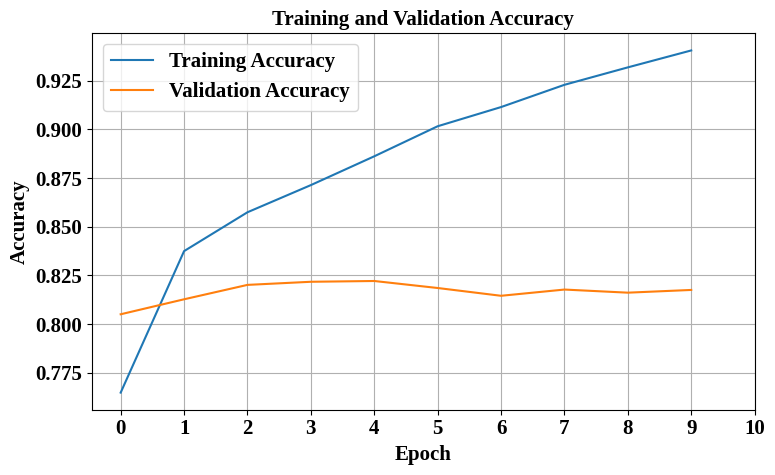

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.xticks(ticks=range(0,11))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("TrainValAccuracy.png")
plt.show()

## Plot of Training and Validation Loss

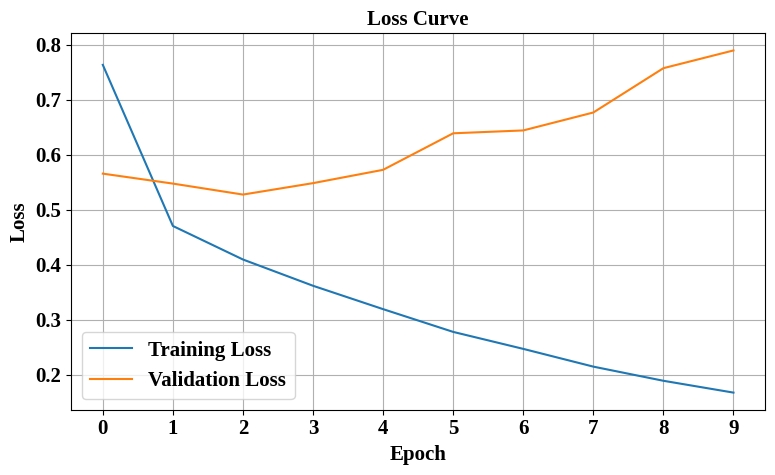

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xticks(ticks=range(0,10))
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("TrainValLoss.png")
plt.show()

# Task 4: Fine Tuning

1. Unfreeze the last convolution block.
2. Train for another 5–10 epochs.
3. Compare the classification accuracy before and after fine tuning.

In [ ]:
# Find the VGG16 base model by name
base_model = model.get_layer('vgg16')

base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(x_train, y_train_cat,
                          validation_data=(x_test, y_test_cat),
                          batch_size=32,
                          epochs=5,
                          verbose=1)

print("Before fine-tuning - Val Acc:", max(history.history['val_accuracy']))
print("After fine-tuning  - Val Acc:", max(history_fine.history['val_accuracy']))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 112s 69ms/step - accuracy: 0.8502 - loss: 0.4686 - val_accuracy: 0.8604 - val_loss: 0.4381
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.9200 - loss: 0.2403 - val_accuracy: 0.8853 - val_loss: 0.3500
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.9435 - loss: 0.1667 - val_accuracy: 0.8991 - val_loss: 0.3109
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.9616 - loss: 0.1167 - val_accuracy: 0.9048 - val_loss: 0.3489
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.9696 - loss: 0.0959 - val_accuracy: 0.9105 - val_loss: 0.3357
Before fine-tuning - Val Acc: 0.8220999836921692
After fine-tuning  - Val Acc: 0.9104999899864197


# Task 5: Model Evaluation
## Evaluate the trained model using
* Accuracy
* Precision
* Recall
* F1-score
* Confusion Matrix
* Classification Report

In [ ]:
y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step


In [ ]:
# Accuracy, Precision, Recall, F1 score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)
recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)
f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)

Accuracy: 0.9105
Recall: 0.9105
Precision: 0.9124063566237557
F1 Score: 0.9107742104848716


In [ ]:
# Classification score
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.97      0.88      0.92      1000
  Automobile       0.96      0.95      0.96      1000
        Bird       0.93      0.90      0.91      1000
         Cat       0.79      0.86      0.83      1000
        Deer       0.87      0.91      0.89      1000
         Dog       0.87      0.83      0.85      1000
        Frog       0.96      0.90      0.93      1000
       Horse       0.90      0.93      0.91      1000
        Ship       0.93      0.97      0.95      1000
       Truck       0.94      0.97      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



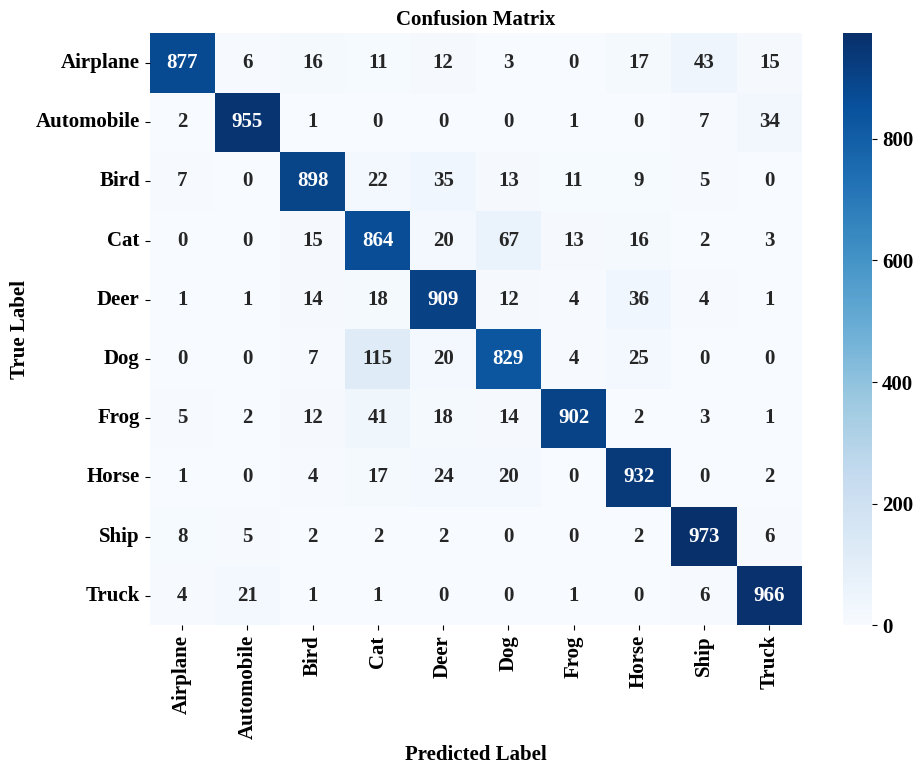

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("ConfusionMatrix.png")
plt.show()

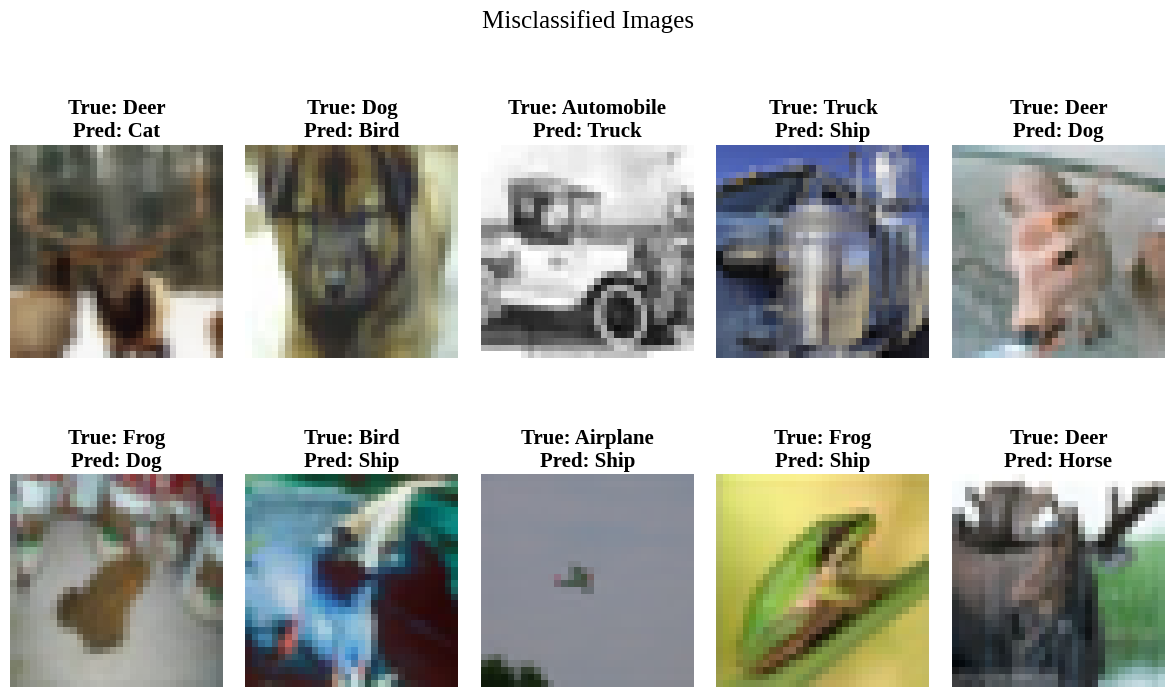

In [ ]:
# misclassified samples
misclassified = np.where(y_true != y_pred)[0]
plt.figure(figsize=(12, 8))
for i, index in enumerate(misclassified[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index])
    plt.title(
        "True: " + class_names[y_true[index]] +
        "\nPred: " + class_names[y_pred[index]]
    )
    plt.axis('off')
plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.savefig("MisclassifiedImages.png")
plt.show()

# Hyperparameter Study

In [ ]:
baseline = {
    'lr': 0.001,
    'batch_size': 32,
    'epochs': 10,
    'optimizer': 'adam',
    'dense_units': 128,
    'frozen': 'all'
}

experiments = [
    baseline,
    {**baseline, 'lr': 0.0001},
    {**baseline, 'batch_size': 16},
    {**baseline, 'batch_size': 64},
    {**baseline, 'epochs': 20},
    {**baseline, 'optimizer': 'sgd'},
    {**baseline, 'dense_units': 256},
    {**baseline, 'frozen': 'partial'},
]

In [ ]:
def get_optimizer(name, lr):
    return Adam(learning_rate=lr) if name == 'adam' else SGD(learning_rate=lr)

results = []

for i, cfg in enumerate(experiments):
    print(f"\nRunning experiment {i+1}/{len(experiments)}: {cfg}")

    model = build_model(dense_units=cfg['dense_units'], frozen=cfg['frozen'])
    model.compile(optimizer=get_optimizer(cfg['optimizer'], cfg['lr']),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    start = time.time()
    hist = model.fit(x_train, y_train_cat,
                      validation_data=(x_test, y_test_cat),
                      batch_size=cfg['batch_size'],
                      epochs=cfg['epochs'],
                      verbose=0)
    elapsed = time.time() - start

    val_acc = max(hist.history['val_accuracy'])
    results.append({**cfg, 'val_accuracy': val_acc, 'time_sec': elapsed})
    print(f"Val Accuracy: {val_acc:.4f} | Time: {elapsed:.1f}s")

results_df = pd.DataFrame(results)
results_df


Running experiment 1/8: {'lr': 0.001, 'batch_size': 32, 'epochs': 10, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all'}
Val Accuracy: 0.8216 | Time: 769.6s

Running experiment 2/8: {'lr': 0.0001, 'batch_size': 32, 'epochs': 10, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all'}
Val Accuracy: 0.8197 | Time: 776.3s

Running experiment 3/8: {'lr': 0.001, 'batch_size': 16, 'epochs': 10, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all'}
Val Accuracy: 0.8195 | Time: 772.2s

Running experiment 4/8: {'lr': 0.001, 'batch_size': 64, 'epochs': 10, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all'}
Val Accuracy: 0.8219 | Time: 711.7s

Running experiment 5/8: {'lr': 0.001, 'batch_size': 32, 'epochs': 20, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all'}
Val Accuracy: 0.8248 | Time: 1527.3s

Running experiment 6/8: {'lr': 0.001, 'batch_size': 32, 'epochs': 10, 'optimizer': 'sgd', 'dense_units': 128, 'frozen': 'all'}
Val Accuracy: 0.8018 | Time: 767.6s

Running 

,lr,batch_size,epochs,optimizer,dense_units,frozen,val_accuracy,time_sec
0,0.0010,32,10,adam,128,all,0.8216,769.603443
1,0.0001,32,10,adam,128,all,0.8197,776.327944
2,0.0010,16,10,adam,128,all,0.8195,772.222132
3,0.0010,64,10,adam,128,all,0.8219,711.689748
4,0.0010,32,20,adam,128,all,0.8248,1527.301772
5,0.0010,32,10,sgd,128,all,0.8018,767.583456
6,0.0010,32,10,adam,256,all,0.8230,767.402967
7,0.0010,32,10,adam,128,partial,0.1000,1001.747210


# Additional exercises
# Conparison of CNN Arcitectures
## Model
* AlexNet
* LeNet -5
* GoogleNet
* ResNet50

In [1]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten
from tensorflow.keras.models import Sequential

def build_lenet5():
    model = Sequential([
        Conv2D(6, (5,5), activation='tanh', padding='same', input_shape=(32,32,3)),
        AveragePooling2D((2,2)),
        Conv2D(16, (5,5), activation='tanh'),
        AveragePooling2D((2,2)),
        Flatten(),
        Dense(120, activation='tanh'),
        Dense(84, activation='tanh'),
        Dense(10, activation='softmax')
    ])
    return model

In [2]:
def build_alexnet():
    model = Sequential([
        Conv2D(96, (3,3), strides=1, activation='relu', padding='same', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D((2,2)),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2,2)),
        Conv2D(384, (3,3), activation='relu', padding='same'),
        Conv2D(384, (3,3), activation='relu', padding='same'),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2,2)),
        Flatten(),
        Dense(4096, activation='relu'),
        Dense(4096, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

In [3]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

def build_googlenet():
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(96,96,3))
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(32,32,3))
    x = tf.keras.layers.Resizing(96,96)(inputs)
    x = inception_preprocess(x * 255.0)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(10, activation='softmax')(x)

    return Model(inputs, outputs)

In [4]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def build_resnet50():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(96,96,3))
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(32,32,3))
    x = tf.keras.layers.Resizing(96,96)(inputs)
    x = resnet_preprocess(x * 255.0)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(10, activation='softmax')(x)

    return Model(inputs, outputs)

In [15]:
architectures = {
    'LeNet-5': build_lenet5(),
    'AlexNet': build_alexnet(),
    'GoogleNet': build_googlenet(),
    'ResNet50': build_resnet50()
}

comparison_results = []

for name, arch_model in architectures.items():

    arch_model.compile(optimizer=Adam(learning_rate=0.001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

    start = time.time()
    hist = arch_model.fit(x_train, y_train_cat,
                            validation_data=(x_test, y_test_cat),
                            batch_size=32,
                            epochs=10,
                            verbose=0)
    elapsed = time.time() - start
    test_acc = max(hist.history['val_accuracy'])

    comparison_results.append({
        'Model': name,
        'Parameters': arch_model.count_params(),
        'Accuracy (%)': round(test_acc * 100, 2),
        'Training Time (s)': round(elapsed, 1)
    })
    print(f"{name}: done")
comparison_df = pd.DataFrame(comparison_results)
comparison_df

LeNet-5: done
AlexNet: done
GoogleNet: done
ResNet50: done


,Model,Parameters,Accuracy (%),Training Time (s)
0,LeNet-5,83126,54.45,77.5
1,AlexNet,36925322,71.19,343.1
2,GoogleNet,22066346,69.58,296.1
3,ResNet50,23851274,86.38,392.7
